# 🍺 Nearest Pubs from Liverpool Street Station
Cloud-native spatial analysis using Overture Maps + ArcGIS Online. Pubs queried directly from S3 via DuckDB — no data downloaded. Walking distances calculated using the ArcGIS OD Cost Matrix service. Only the result is saved.

In [1]:
# Setup
import warnings, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

from arcgis.gis import GIS
from arcgis.features import GeoAccessor, FeatureSet
from arcgis.geometry import Point, Polyline
from arcgis.geoprocessing import import_toolbox
import pandas as pd
import matplotlib.pyplot as plt
import json, time, duckdb

gis = GIS('home')

print(f"DuckDB version: {duckdb.__version__}")

DuckDB version: 1.3.2


In [2]:
# Connect DuckDB to Overture Maps on S3
conn = duckdb.connect()
conn.sql('INSTALL spatial; LOAD spatial;')
conn.sql('INSTALL httpfs; LOAD httpfs;')
conn.sql("SET s3_region='us-west-2';")
conn.sql('SET enable_object_cache = true;')

RELEASE      = '2026-02-18.0'
STATION_X    = -0.0823
STATION_Y    =  51.5178
xmin, ymin   = -0.100, 51.510
xmax, ymax   = -0.065, 51.525

print(f"Overture release : {RELEASE}")
print(f"Area of interest : ({xmin},{ymin}) -> ({xmax},{ymax})")

Overture release : 2026-02-18.0
Area of interest : (-0.1,51.51) -> (-0.065,51.525)


In [3]:
# Query pubs directly from Overture S3 parquet — no data downloaded
sql = f"""
SELECT
    id,
    names.primary          AS name,
    categories.primary     AS category,
    ST_AsGeoJSON(geometry) AS geojson
FROM read_parquet(
    's3://overturemaps-us-west-2/release/{RELEASE}/theme=places/type=place/*.parquet',
    filename=false, hive_partitioning=1
)
WHERE bbox.xmin >= {xmin} AND bbox.ymin >= {ymin}
  AND bbox.xmax <= {xmax} AND bbox.ymax <= {ymax}
  AND categories.primary IN ('pub', 'bar', 'cocktail_bar', 'wine_bar')
"""

pubs_df = conn.sql(sql).df()
print(f"Found {len(pubs_df)} pubs and bars near Liverpool Street")
pubs_df[['name', 'category']].head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Found 616 pubs and bars near Liverpool Street


,name,category
0,The Dog,pub
1,The Oliver Conquest,pub
2,Club Oops,pub
3,The Black Horse,pub
4,The Dispensary,pub
5,Leman Bar Lounge,bar
6,Bar + Block Steakhouse London Aldgate,bar
7,Leman Street Tavern,pub
8,The Running Horse,pub
9,Boom Battle Bar,bar


In [4]:
# Convert GeoJSON to ArcGIS Point geometry and activate spatial accessor
def geojson_to_point(s):
    gj = json.loads(s)
    return Point({'x': gj['coordinates'][0], 'y': gj['coordinates'][1],
                  'spatialReference': {'wkid': 4326}})

pubs_df['SHAPE'] = pubs_df['geojson'].apply(geojson_to_point)
pubs_df.drop(columns=['geojson'], inplace=True)
pubs_df.spatial.set_geometry('SHAPE')

# Define Liverpool Street Station as single origin
liverpool_st = pd.DataFrame([{
    'name' : 'Liverpool Street Station',
    'SHAPE': Point({'x': STATION_X, 'y': STATION_Y,
                    'spatialReference': {'wkid': 4326}})
}])
liverpool_st.spatial.set_geometry('SHAPE')
print(f"{len(pubs_df)} pub locations ready")

616 pub locations ready


In [5]:
# Run OD Cost Matrix — real walking distances along the street network
od_tb = import_toolbox(
    'https://logistics.arcgis.com/arcgis/rest/services/World/OriginDestinationCostMatrix/GPServer',
    gis=gis
)

print(f"Running OD Cost Matrix: Liverpool Street -> {len(pubs_df)} destinations...")

result = od_tb.generate_origin_destination_cost_matrix(
    origins                        = FeatureSet.from_dataframe(liverpool_st[['name', 'SHAPE']]),
    destinations                   = FeatureSet.from_dataframe(pubs_df[['id', 'name', 'SHAPE']]),
    travel_mode                    = 'Walking Distance',
    number_of_destinations_to_find = len(pubs_df),
    gis                            = gis
)

print(f"Solve succeeded : {result.solve_succeeded}")
print(f"Credits used    : {result.usage_cost}")

Running OD Cost Matrix: Liverpool Street -> 616 destinations...


/opt/conda/lib/python3.13/site-packages/arcgis/features/geo/_accessor.py:1657: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._data[col] = array


Solve succeeded : True
Credits used    : {'numObjects': 616, 'credits': 0.308}


In [6]:
# Extract results and join walk times back to pub points
od_df = result.output_origin_destination_lines.sdf
od_df['Distance_km'] = (od_df['Total_Distance'] / 1000).round(2)
od_df['Time_mins']   =  od_df['Total_Time'].round(1)

pubs_plot = pubs_df.merge(
    od_df[['DestinationName', 'Distance_km', 'Time_mins', 'DestinationRank']],
    left_on='name', right_on='DestinationName', how='left'
)
pubs_plot.spatial.set_geometry('SHAPE')

print(f"{len(pubs_plot)} pubs ranked by walking time from Liverpool Street\n")
print("Top 10 nearest:")
pubs_plot[['name', 'category', 'Distance_km', 'Time_mins']].sort_values('Time_mins').head(10)

718 pubs ranked by walking time from Liverpool Street

Top 10 nearest:


,name,category,Distance_km,Time_mins
231,The Parcel Office,bar,0.0,0.2
232,"Railway Pub, Liverpool Street",pub,0.0,0.6
328,1901 Restaurant,bar,0.0,0.7
230,Lord Aberconway,pub,0.0,0.9
233,The Railway Tavern,pub,0.0,0.9
329,The George,pub,0.0,1.0
330,Lady Abercorn's Pub and Kitchen,pub,0.0,1.2
331,Williams Trading Uk Limited,pub,0.0,1.2
253,The Merchant of Bishopsgate,pub,0.0,1.3
339,Devonshire Business Services,bar,0.0,1.4


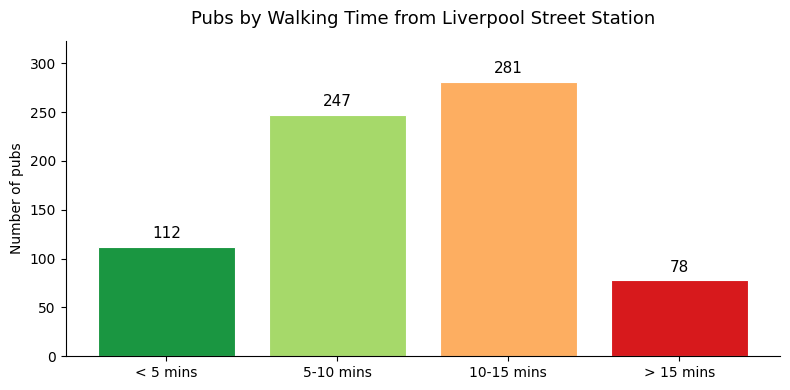

In [7]:
# Walking time breakdown — bar chart
bands  = ['< 5 mins', '5-10 mins', '10-15 mins', '> 15 mins']
counts = [
    len(pubs_plot[pubs_plot['Time_mins'] <= 5]),
    len(pubs_plot[(pubs_plot['Time_mins'] > 5)  & (pubs_plot['Time_mins'] <= 10)]),
    len(pubs_plot[(pubs_plot['Time_mins'] > 10) & (pubs_plot['Time_mins'] <= 15)]),
    len(pubs_plot[pubs_plot['Time_mins'] > 15])
]
colors = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bands, counts, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Pubs by Walking Time from Liverpool Street Station', fontsize=13, pad=12)
ax.set_ylabel('Number of pubs')
ax.set_ylim(0, max(counts) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
m = gis.map('Liverpool Street, London')


pubs_plot.spatial.plot(
    map_widget    = m,
    renderer_type = 's',
    symbol_type   = 'simple',
    symbol_style  = 'circle',
    colors        = '#1a9641',
    marker_size   = 8,
    opacity       = 0.9
)

m

Map()

In [9]:
# Heatmap — density of pubs reachable within 10 minutes walk
within10 = pubs_plot[pubs_plot['Time_mins'] <= 10].copy()
print(f"{len(within10)} pubs within 10 minutes walk of Liverpool Street")

heat_df = pd.DataFrame({
    'Time_mins': within10['Time_mins'].astype(float).values,
    'SHAPE'    : within10['SHAPE'].apply(
                     lambda g: Point({'x': float(g['x']), 'y': float(g['y']),
                                      'spatialReference': {'wkid': 4326}})
                 ).values
})
heat_df.spatial.set_geometry('SHAPE')

heat_layer = heat_df.spatial.to_featurelayer('Pubs Heatmap', gis=gis)
heat_layer.layers[0].manager.update_definition({
    'drawingInfo': {
        'renderer': {
            'type'             : 'heatmap',
            'field'            : 'Time_mins',
            'blurRadius'       : 14,
            'maxPixelIntensity': 100,
            'minPixelIntensity': 0,
            'colorStops': [
                {'color': [0,   0,   255, 0],   'ratio': 0.0},
                {'color': [0,   255, 0,   255], 'ratio': 0.4},
                {'color': [255, 255, 0,   255], 'ratio': 0.7},
                {'color': [255, 0,   0,   255], 'ratio': 1.0}
            ]
        }
    }
})

m2 = gis.map('Liverpool Street, London')
m2.content.add(heat_layer)
m2

359 pubs within 10 minutes walk of Liverpool Street


/opt/conda/lib/python3.13/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Map()

In [ ]:
# Save enriched pub points to AGO — raw Overture data never stored
save_df = pubs_plot[['name', 'category', 'DestinationRank', 'Distance_km', 'Time_mins', 'SHAPE']].copy()

published = save_df.spatial.to_featurelayer(
    title       = 'Pubs Walking Distance from Liverpool Street Station',
    gis         = gis,
    tags        = 'Overture, Pubs, OD Matrix, London, Liverpool Street',
    description = f'Walking distance from Liverpool Street Station to {len(save_df)} pubs. '
                  f'Overture Maps release {RELEASE}. Raw source data not stored.'
)
print(f"Saved {len(save_df)} pubs to ArcGIS Online")
print(f"Item URL: {published.homepage}")